In [1]:
##Import packages
import numpy as np
import matplotlib.pyplot as plt
import bezier
import plotly.express as px
import plotly.graph_objects as go
import plotly
plotly.offline.init_notebook_mode(connected=True)

from numpy.random import default_rng

from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import mean_squared_error

import umap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

from sklearn import datasets, manifold

import GPy





2025-05-20 13:27:49.521391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747772869.655106 1241364 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747772869.692330 1241364 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747772869.974014 1241364 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747772869.974057 1241364 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747772869.974059 1241364 computation_placer.cc:177] computation placer alr

# Manifolds

In [2]:
# M1 Manifolds in R3

def my_circle():
    theta = np.linspace(0, 2*np.pi, 1000)
    x = np.cos(theta)
    y = np.sin(theta)
    z = np.zeros_like(theta)
    return np.array([x,y,z]).T

def my_helix():
    theta = np.linspace(0, 4*np.pi, 1000)
    x = np.cos(theta)
    y = np.sin(theta)
    z = theta / 4
    return np.array([x,y,z]).T

def my_line():
    theta = np.linspace(-2, 2, 1000)
    x = theta
    y = theta
    z = theta
    return np.array([x,y,z]).T

def my_curved_line():
    np.random.seed(42)
    N = 5
    nodes = []
    curve = []
    
    for i in range(N):
        nodes.append(np.asfortranarray(np.random.rand(3,3)))
        curve.append(bezier.Curve(nodes[i], degree=2))
    
    theta = np.linspace(0,1,1000)
    c = np.empty((1000,3))
    for j in range(1000):
        c[j] = curve[i].evaluate(theta[j])[:,0]
    return c


In [3]:
def my_2DS():
    n_samples = 1500
    S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)
    return S_points

def my_2Dsphere():
    theta = np.linspace(0, np.pi, 50)
    phi = np.linspace(0, 2*np.pi, 50)
    theta, phi = np.meshgrid(theta, phi)
    
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Flatten and stack
    return np.column_stack((x.ravel(), y.ravel(), z.ravel()))


def my_2Dtorus(R=2, r=0.5, n_points_major=50, n_points_minor=50):
    """
    Generates a torus surface as an (N, 3) array, with each row [x, y, z].

    Parameters:
        R (float): Major radius (distance from center of tube to center of torus)
        r (float): Minor radius (radius of the tube)
        n_points_major (int): Number of points along the main circle (phi)
        n_points_minor (int): Number of points along the tube (psi)

    Returns:
        points (ndarray): Array of shape (n_points_major * n_points_minor, 3)
    """
    phi = np.linspace(0, 2 * np.pi, n_points_major)
    psi = np.linspace(0, 2 * np.pi, n_points_minor)
    phi, psi = np.meshgrid(phi, psi)

    x = (R + r * np.cos(psi)) * np.cos(phi)
    y = (R + r * np.cos(psi)) * np.sin(phi)
    z = r * np.sin(psi)

    points = np.column_stack((x.ravel(), y.ravel(), z.ravel()))
    return points



In [4]:
# Choose one of the following manifolds
c = my_line()
c = my_curved_line()
c = my_helix()
c = my_circle()
c = my_2DS()
c = my_2Dsphere()
c = my_2Dtorus()

fig = go.Figure(data=[go.Scatter3d(
    x=c[:,0],y=c[:,1],z=c[:,2], mode='markers', marker=dict( size=5, color=c[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

len of Y:  2500


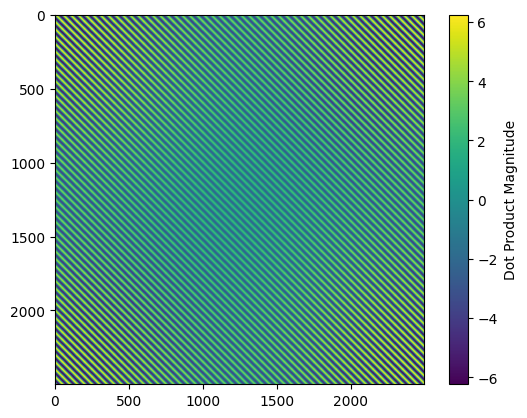

In [5]:
# Creating a sparse training set
Y = c#[::20]
print("len of Y: ", len(Y))

# fig = px.scatter_3d(x=Y[:, 0], y=Y[:, 1], z=Y[:, 2])
# fig.update_layout(scene=dict(aspectmode='cube'))
# fig.show()

#print(Y)
plt.imshow(Y @ Y.T) # Plotting the covariance between the points
cbar = plt.colorbar()
cbar.set_label('Dot Product Magnitude')  # Optional: Label for the colorbar
# Show the plot
plt.show()

In [6]:
fig = go.Figure(data=[go.Scatter3d(
    x=Y[:,0],y=Y[:,1],z=Y[:,2], mode='markers', marker=dict( size=5, color=Y[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

## PCA


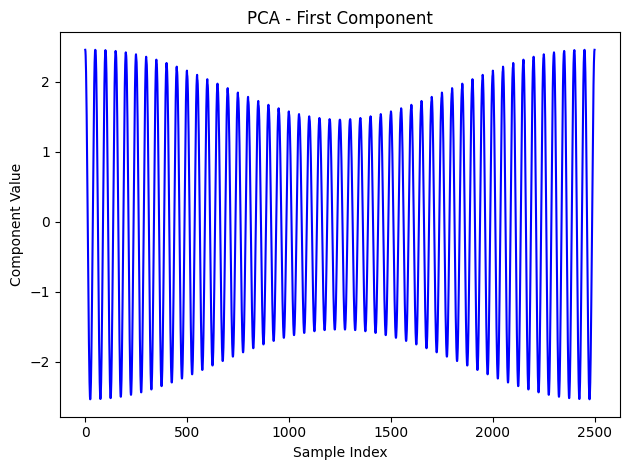

In [7]:
# PCA and kernel PCA

num_components = 1

pca = PCA(n_components=num_components)

X_test_pca = pca.fit(Y).transform(Y)

# # Create figure with two horizontal subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# # PCA plot
# #ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], color='blue')
# ax1.plot(X_test_pca[:, 0], color='blue')
# ax1.set_title("PCA - First Component")
# ax1.set_xlabel("Sample Index")
# ax1.set_ylabel("Component Value")
# # Kernel PCA plot
# #ax2.plot(X_test_kernel_pca[:, 0],X_test_kernel_pca[:, 1], color='red')
# ax2.plot(X_test_kernel_pca[:, 0], color='red')
# ax2.set_title("Kernel PCA - First Component")
# ax2.set_xlabel("Sample Index")
# plt.tight_layout()
# plt.show()


plt.plot(X_test_pca[:, 0], color='blue')
plt.title("PCA - First Component")
plt.xlabel("Sample Index")
plt.ylabel("Component Value")
plt.tight_layout()
plt.show()


In [8]:
# Compute the inverse of PCA
Y_reconstructed_pca = pca.inverse_transform(X_test_pca)

# Verify shape
#print(f"Original shape: {Y.shape}, Reconstructed shape: {Y_reconstructed_pca.shape}")

print("PCA MSE:", mean_squared_error(Y, Y_reconstructed_pca))

# Plotting the PCA reconstructed manifold
fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed_pca[:, 0],y=Y_reconstructed_pca[:, 1], z=Y_reconstructed_pca[:, 2], mode='markers', marker=dict( size=5, color=Y_reconstructed_pca[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()



PCA MSE: 0.7215250000000001


## Kernel PCA

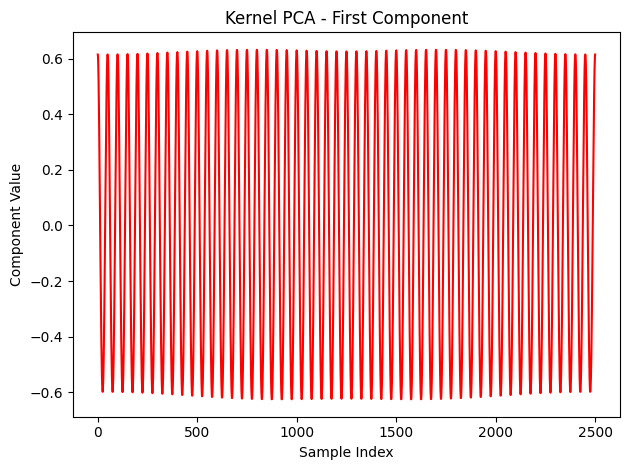

Kernel PCA MSE: 0.7462630226198147


In [9]:
my_gamma = 1/(Y.shape[1] * Y.var())  # Auto-scale to data variance

kernel_pca = KernelPCA(n_components=num_components, kernel="rbf", gamma=my_gamma, fit_inverse_transform=True, alpha=1e-4)

X_test_kernel_pca = kernel_pca.fit(Y).transform(Y)

# Kernel PCA plot

plt.plot(X_test_kernel_pca[:, 0], color='red')
plt.title("Kernel PCA - First Component")
plt.xlabel("Sample Index")
plt.ylabel("Component Value")
plt.tight_layout()
plt.show()

# Compute the inverse of kernel PCA
Y_reconstructed_kpca = kernel_pca.inverse_transform(X_test_kernel_pca)

# Verify shape
#print(f"Original shape: {Y.shape}, Reconstructed shape: {Y_reconstructed_kpca.shape}")

print("Kernel PCA MSE:", mean_squared_error(Y, Y_reconstructed_kpca))

# Plotting the kernel PCA reconstructed manifold
fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed_kpca[:, 0],y=Y_reconstructed_kpca[:, 1], z=Y_reconstructed_kpca[:, 2], mode='markers', marker=dict( size=5, color=Y_reconstructed_kpca[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()



## UMAP

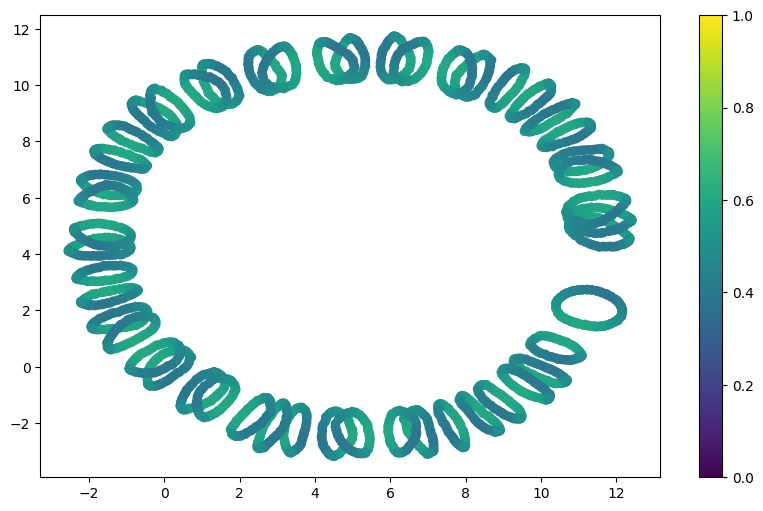

In [10]:
def fit_umap(data,n_neighbors=15, min_dist=0.01, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        #random_state=1,  # Controls model initialization
        transform_seed=43,  # Controls transform() randomness
        n_epochs=1000,  # Longer training for stability
        n_jobs=1,  # Disable parallel processing for reproducibility
        #verbose=True  # Monitor convergence
    )
    u = fit.fit_transform(data)
    return u, fit
    
def plot_umap(u, data, title=""):
    n_components = u.shape[1]
    fig = plt.figure(figsize=(10, 6))
    
    # Normalize color data to [0,1] range
    norm_data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    if n_components == 2:
        ax = fig.add_subplot(111)
        sc = ax.scatter(u[:,0], u[:,1], c=norm_data[:,2], cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(sc)
        
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=norm_data[:,2], cmap='viridis')
        plt.colorbar(sc)
    
    plt.title(title)


u, fit = fit_umap(Y,n_neighbors=15, min_dist=0.05, n_components=2, metric='euclidean', title='')

plot_umap(u, Y)

In [11]:
# Calculate the reconstruction from the UMAP

# Reconstruct data from the embedding
Y_reconstructed_umap = fit.inverse_transform(u)  # ✅ Use the model, not the array

print("UMAP MSE:", mean_squared_error(Y, Y_reconstructed_umap))

fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed_umap[:, 0],y=Y_reconstructed_umap[:, 1], z=Y_reconstructed_umap[:, 2], mode='markers', marker=dict( size=5, color=Y_reconstructed_umap[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


UMAP MSE: 0.005663804200946411


In [12]:
total_variance = np.var(Y)
mse = np.mean((Y - Y_reconstructed_umap) ** 2)
perc_mse = 100 * mse / total_variance
print(f"MSE is {perc_mse:.2f}% of the total variance.")

mean_sq_orig = np.mean(Y ** 2)
perc_mse = 100 * mse / mean_sq_orig
print(f"MSE is {perc_mse:.2f}% of the mean squared value.")

from sklearn.metrics import r2_score
r2 = r2_score(Y, Y_reconstructed_umap)
print(f"Explained variance (R²): {r2 * 100:.2f}%")

MSE is 0.40% of the total variance.
MSE is 0.40% of the mean squared value.
Explained variance (R²): 96.23%


## GPLVM using GPy

Mean Squared Error between original and reconstructed: 0.0000


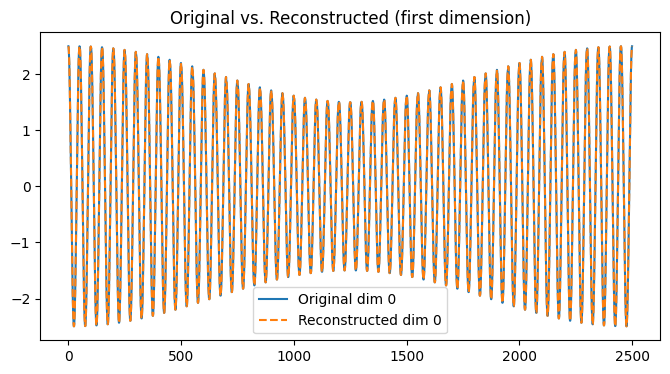

In [13]:
# Generate synthetic high-dimensional data


latent_dim = u.shape[1]

# Create GPLVM with UMAP initialization
gplvm = GPy.models.GPLVM(Y, input_dim=latent_dim,  X=u, kernel=GPy.kern.RBF(latent_dim)) # 

gplvm.optimize(messages=True, max_iters=100)

# Extract latent variables
X_latent = gplvm.X.values

# Reconstruct the data from the latent variables
# This gives the mean prediction for each latent point
Y_reconstructed, Y_reconstructed_var = gplvm.predict(X_latent)

# Compare the original and reconstructed data
mse = mean_squared_error(Y, Y_reconstructed)
print(f"Mean Squared Error between original and reconstructed: {mse:.4f}")

# Optionally, plot first dimension of original vs reconstructed for a visual check
plt.figure(figsize=(8,4))
plt.plot(Y[:, 0], label='Original dim 0')
plt.plot(Y_reconstructed[:, 0], label='Reconstructed dim 0', linestyle='dashed')
plt.legend()
plt.title('Original vs. Reconstructed (first dimension)')
plt.show()

In [14]:
fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed[:,0],y=Y_reconstructed[:,1],z=Y_reconstructed[:,2], mode='markers', marker=dict( size=5, color=Y_reconstructed[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

In [15]:
total_variance = np.var(Y)
mse = np.mean((Y - Y_reconstructed) ** 2)
perc_mse = 100 * mse / total_variance
print(f"MSE is {perc_mse:.2f}% of the total variance.")

MSE is 0.00% of the total variance.


In [16]:
# fig = go.Figure()

# # Add each trace with a unique colorscale
# fig.add_trace(go.Scatter3d(
#     x=Y_reconstructed_pca[:, 0],
#     y=Y_reconstructed_pca[:, 1],
#     z=Y_reconstructed_pca[:, 2],
#     mode='markers',
#     name='PCA',
#     marker=dict(
#         size=5,
#         color=Y_reconstructed_pca[:, 2],
#         colorscale='Viridis',
#         opacity=0.8
#     )
# ))

# fig.add_trace(go.Scatter3d(
#     x=Y_reconstructed_kpca[:, 0],
#     y=Y_reconstructed_kpca[:, 1],
#     z=Y_reconstructed_kpca[:, 2],
#     mode='markers',
#     name='Kernel PCA',
#     marker=dict(
#         size=5,
#         color=Y_reconstructed_kpca[:, 2],
#         colorscale='Plasma',
#         opacity=0.8
#     )
# ))

# fig.add_trace(go.Scatter3d(
#     x=Y_reconstructed_umap[:, 0],
#     y=Y_reconstructed_umap[:, 1],
#     z=Y_reconstructed_umap[:, 2],
#     mode='markers',
#     name='UMAP',
#     marker=dict(
#         size=5,
#         color=Y_reconstructed_umap[:, 2],
#         colorscale='Inferno',
#         opacity=0.8
#     )
# ))

# fig.add_trace(go.Scatter3d(
#     x=Y_reconstructed[:, 0],
#     y=Y_reconstructed[:, 1],
#     z=Y_reconstructed[:, 2],
#     mode='markers',
#     name='GPLVM',
#     marker=dict(
#         size=5,
#         color=Y_reconstructed[:, 2],
#         colorscale='Electric',
#         opacity=0.8
#     )
# ))

# fig.update_layout(
#     scene=dict(
#         aspectmode='cube',
#         xaxis_title='X',
#         yaxis_title='Y',
#         zaxis_title='Z',
#         camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
#     ),
#     width=600,
#     height=600,
#     margin=dict(r=30, b=20, l=20, t=20)
# )

# fig.show()

# geodesic Distance

In [17]:
from sklearn.neighbors import kneighbors_graph

k = 20  # Adjust as needed
W = kneighbors_graph(Y, n_neighbors=k, mode='distance', include_self=False)


In [18]:
from scipy.sparse.csgraph import shortest_path

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)

geo_dist_matrix

array([[0.00000000e+00, 3.20351100e-01, 6.40702200e-01, ...,
        6.40702200e-01, 3.20351100e-01, 6.24449793e-16],
       [3.20351100e-01, 0.00000000e+00, 3.20351100e-01, ...,
        9.61053300e-01, 6.40702200e-01, 3.20351100e-01],
       [6.40702200e-01, 3.20351100e-01, 0.00000000e+00, ...,
        1.28140440e+00, 9.61053300e-01, 6.40702200e-01],
       ...,
       [6.40702200e-01, 9.61053300e-01, 1.28140440e+00, ...,
        0.00000000e+00, 3.20351100e-01, 6.40702200e-01],
       [3.20351100e-01, 6.40702200e-01, 9.61053300e-01, ...,
        3.20351100e-01, 0.00000000e+00, 3.20351100e-01],
       [6.24449793e-16, 3.20351100e-01, 6.40702200e-01, ...,
        6.40702200e-01, 3.20351100e-01, 0.00000000e+00]])

In [19]:
def retrieve_geodesic_path(source, target, predecessors):
    """Return the list of indices along the shortest path from source to target."""
    path = []
    k = target
    if predecessors[source, k] == -9999:  # no path
        return None
    while k != source:
        path.append(k)
        k = predecessors[source, k]
    path.append(source)
    return path[::-1]

# Example: get geodesic path between two random points
i, j = 20, 1499
path_indices = retrieve_geodesic_path(i, j, predecessors)
print("Indices along path:", path_indices)
print("Geodesic distance:", geo_dist_matrix[i, j])

Indices along path: [20, 2420, 2170, 2069, 1968, 1867, 1716, 1615, 1514, 1463, 1412, 1361, 1360, 1359, 1358, 1357, 1356, 1355, 1354, 1353, 1352, 1401, 1499]
Geodesic distance: 4.936610235790361


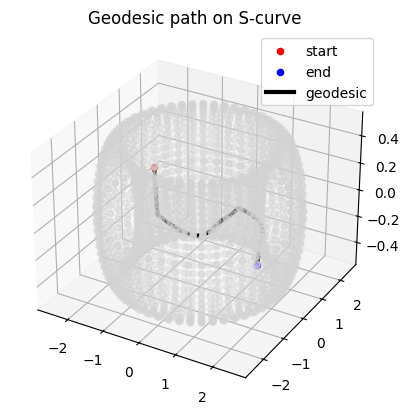

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y[:,0], Y[:,1], Y[:,2], c='lightgray', alpha=0.4)
ax.scatter(Y[i,0], Y[i,1], Y[i,2], color='red', label='start')
ax.scatter(Y[j,0], Y[j,1], Y[j,2], color='blue', label='end')
if path_indices is not None:
    path_pts = Y[path_indices]
    ax.plot(path_pts[:,0], path_pts[:,1], path_pts[:,2], 'k-', lw=3, label='geodesic')
ax.set_title("Geodesic path on S-curve")
ax.legend()
plt.show()